**Linear Separability and Support Vectors**  
- **Dataset:** from sklearn.datasets import make_blobs  
- **Task:** Generate a synthetic, perfectly linearly separable 2D dataset using make_blobs from sklearn.datasets.
- **Action:** Train a Linear SVM (kernel='linear'). Extract the coordinates of the Support Vectors from the trained model and plot the data points, highlighting the support vectors and drawing the separating hyperplane (decision boundary)

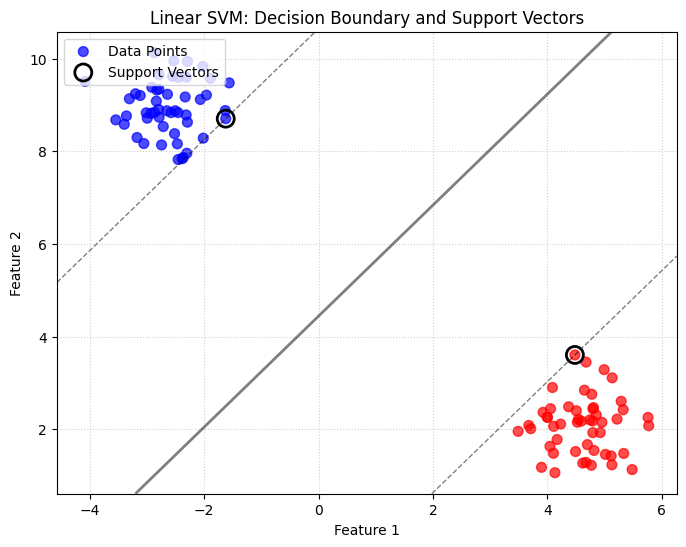

Coordinates of the Support Vectors:
 [[-1.6224612   8.703324  ]
 [ 4.48108474  3.60527118]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# 1. Generate a perfectly linearly separable 2D dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=0.60)

# 2. Train a Linear SVM (using a high C value to ensure a hard margin / no misclassifications)
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

# 3. Extract Support Vectors
support_vectors = model.support_vectors_

# 4. Plotting
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr', alpha=0.7, label='Data Points')

# Highlight the Support Vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150,
            facecolors='none', edgecolors='black', linewidths=2, label='Support Vectors')

# Create a mesh to plot the decision boundary and margins
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary (Z=0) and margins (Z=-1, Z=1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

plt.title("Linear SVM: Decision Boundary and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Print the extracted Support Vector coordinates
print("Coordinates of the Support Vectors:\n", support_vectors)

**The Kernel Trick**  
- **Dataset:** from sklearn.datasets import make_moons  
- **Task:** Generate a non-linearly separable dataset (e.g., using make_moons or make_circles).  
- **Action:** Train three different SVM models on this data: one with a Linear kernel, one with a Polynomial kernel, and one with an RBF (Radial Basis Function) kernel. Plot the decision boundaries for all three to visually demonstrate how the Kernel Trick allows SVM to solve non-linear problems.

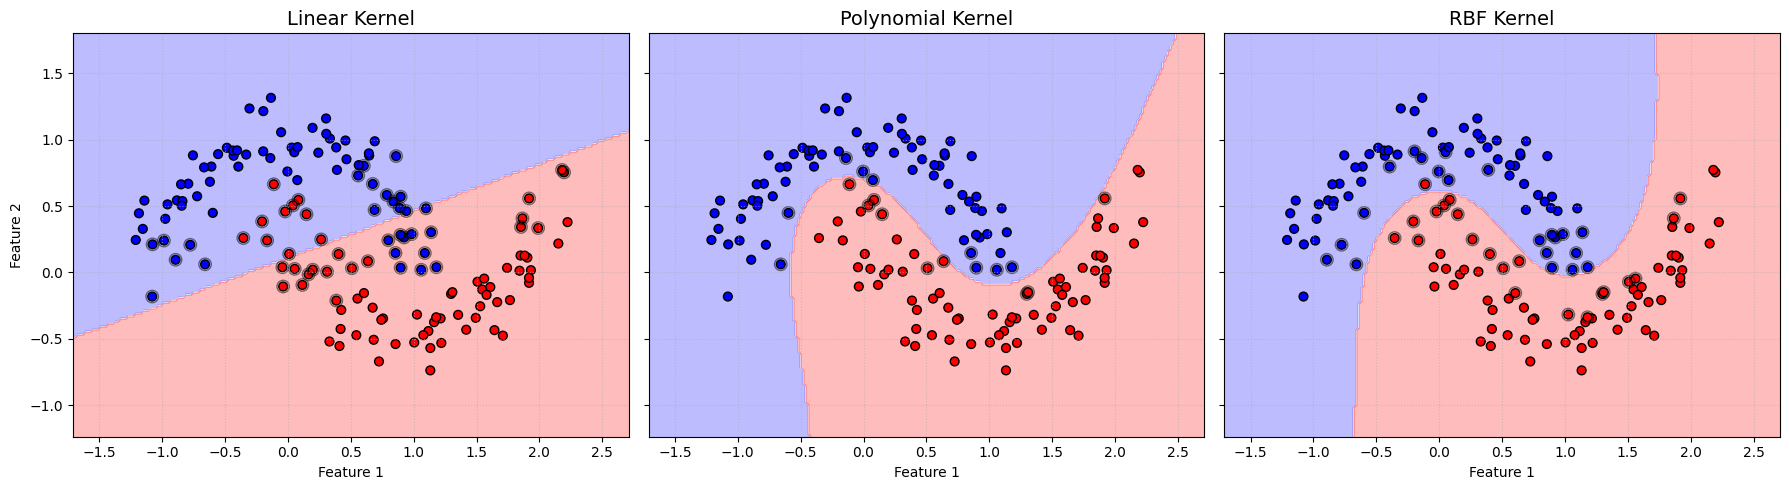

In [2]:
 import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# 1. Generate a non-linearly separable dataset
X, y = make_moons(n_samples=150, noise=0.15, random_state=42)

# 2. Define the three SVM models with different kernels
models = {
    "Linear Kernel": SVC(kernel='linear'),
    "Polynomial Kernel": SVC(kernel='poly', degree=3, coef0=1, C=5),
    "RBF Kernel": SVC(kernel='rbf', gamma=1, C=1)
}

# 3. Plotting the decision boundaries side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Create a meshgrid for plotting boundaries
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

for ax, (title, model) in zip(axes, models.items()):
    # Train the model
    model.fit(X, y)
    
    # Predict over the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary contours
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    
    # Plot the original data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=40)
    
    # Highlight support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
               s=80, facecolors='none', edgecolors='k', alpha=0.5, label='Support Vectors')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Feature 1")
    if title == "Linear Kernel":
        ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()